# AI-Driven Customer Segmentation & Credit Risk Modelling for Financial Decision-Making

 1. Project Introduction
 2. Import Libraries
 3. Load Datasets
 4. Customer Segmentation Analysis
 5. Credit Risk Analysis
 6. Combined Business Insights
 7. Ethical Considerations
 8. Conclusion

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

In [2]:
data_path = "../data"

cc_file = os.path.join(data_path, "CC GENERAL.csv")
loan_file = os.path.join(data_path, "loan_portfolio.csv")
ratings_file = os.path.join(data_path, "credit_ratings.csv")
stress_file = os.path.join(data_path, "macro_stress_scenarios.csv")
metrics_file = os.path.join(data_path, "portfolio_metrics.csv")
vintage_file = os.path.join(data_path, "vintage_analysis.csv")

In [3]:
cc_df = pd.read_csv(cc_file)
loan_df = pd.read_csv(loan_file)
ratings_df = pd.read_csv(ratings_file)
stress_df = pd.read_csv(stress_file)
metrics_df = pd.read_csv(metrics_file)
vintage_df = pd.read_csv(vintage_file)

print("CC dataset shape:", cc_df.shape)
print("Loan dataset shape:", loan_df.shape)
print("Ratings dataset shape:", ratings_df.shape)
print("Stress dataset shape:", stress_df.shape)
print("Metrics dataset shape:", metrics_df.shape)
print("Vintage dataset shape:", vintage_df.shape)

CC dataset shape: (8950, 18)
Loan dataset shape: (50000, 24)
Ratings dataset shape: (17939, 9)
Stress dataset shape: (60, 16)
Metrics dataset shape: (120, 16)
Vintage dataset shape: (2160, 9)


In [4]:
display(cc_df.head())
display(loan_df.head())

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


,loan_id,origination_date,maturity_date,maturity_months,sector,loan_type,collateral,initial_rating,credit_score,ead,coupon_rate,leverage,interest_coverage,debt_to_equity,pd_annual,lgd,el,unexpected_loss,rwa,defaulted,default_date,survival_months,recovery_rate,loss_given_default
0,L000001,2017-10-01,2019-10-01,24,Technology,mortgage,secured,B,704,1035611.99,3.776,6.54,3.47,1.40,0.041076,0.7858,33426.80,161508.03,442905.14,0,NaN,24,NaN,NaN
1,L000002,2016-06-01,2020-06-01,48,Healthcare,term_loan,unsecured,A,702,800786.92,3.895,12.26,4.47,2.77,0.000887,0.7034,499.82,16771.62,6622.66,0,NaN,48,NaN,NaN
2,L000003,2023-08-01,2024-12-31,36,Real_Estate,bond,secured,BBB,699,4327864.12,4.365,8.98,6.02,2.18,0.002622,0.5503,6243.54,121781.72,82726.94,0,NaN,36,NaN,NaN
3,L000004,2016-04-01,2024-12-31,120,Real_Estate,term_loan,secured,B,641,3810461.19,3.749,13.12,5.93,1.75,0.041679,0.3541,56237.33,269661.85,745144.64,0,NaN,120,NaN,NaN
4,L000005,2015-10-01,2019-10-01,48,Energy,bond,unsecured,CCC,597,2925538.53,5.231,1.80,4.39,1.79,0.136071,0.6576,261778.69,659614.05,3468567.58,0,NaN,48,NaN,NaN


In [5]:
print("CC GENERAL info:")
display(cc_df.info())

print("\nLoan portfolio info:")
display(loan_df.info())

CC GENERAL info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   in

None


Loan portfolio info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             50000 non-null  object 
 1   origination_date    50000 non-null  object 
 2   maturity_date       50000 non-null  object 
 3   maturity_months     50000 non-null  int64  
 4   sector              50000 non-null  object 
 5   loan_type           50000 non-null  object 
 6   collateral          50000 non-null  object 
 7   initial_rating      50000 non-null  object 
 8   credit_score        50000 non-null  int64  
 9   ead                 50000 non-null  float64
 10  coupon_rate         50000 non-null  float64
 11  leverage            50000 non-null  float64
 12  interest_coverage   50000 non-null  float64
 13  debt_to_equity      50000 non-null  float64
 14  pd_annual           50000 non-null  float64
 15  lgd                 50000 non-n

None

In [6]:
print("Missing values in CC GENERAL:")
display(cc_df.isnull().sum().sort_values(ascending=False))

print("\nMissing values in loan portfolio:")
display(loan_df.isnull().sum().sort_values(ascending=False))

Missing values in CC GENERAL:


MINIMUM_PAYMENTS                    313
CREDIT_LIMIT                          1
BALANCE                               0
CUST_ID                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
PURCHASES_INSTALLMENTS_FREQUENCY      0
ONEOFF_PURCHASES_FREQUENCY            0
CASH_ADVANCE_TRX                      0
CASH_ADVANCE_FREQUENCY                0
PURCHASES_TRX                         0
PAYMENTS                              0
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


Missing values in loan portfolio:


default_date          43050
recovery_rate         43050
loss_given_default    43050
loan_id                   0
sector                    0
origination_date          0
maturity_date             0
maturity_months           0
initial_rating            0
collateral                0
loan_type                 0
credit_score              0
interest_coverage         0
ead                       0
coupon_rate               0
leverage                  0
lgd                       0
pd_annual                 0
debt_to_equity            0
el                        0
defaulted                 0
rwa                       0
unexpected_loss           0
survival_months           0
dtype: int64

In [7]:
print("CC GENERAL columns:")
print(cc_df.columns.tolist())

print("\nLoan Portfolio columns:")
print(loan_df.columns.tolist())

CC GENERAL columns:
['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

Loan Portfolio columns:
['loan_id', 'origination_date', 'maturity_date', 'maturity_months', 'sector', 'loan_type', 'collateral', 'initial_rating', 'credit_score', 'ead', 'coupon_rate', 'leverage', 'interest_coverage', 'debt_to_equity', 'pd_annual', 'lgd', 'el', 'unexpected_loss', 'rwa', 'defaulted', 'default_date', 'survival_months', 'recovery_rate', 'loss_given_default']


## 1. Project Introduction

This project combines two machine learning approaches to support financial decision-making.

First, customer segmentation is performed using unsupervised learning on credit card behavioural data to identify distinct customer groups.

Second, credit risk modelling is performed using loan portfolio data to analyse default-related behaviour and estimate financial risk.

The overall aim is to understand how customer behaviour patterns and credit risk indicators can be used together to support better business and lending decisions.

## 4. Customer Segmentation Analysis

In this section, we perform customer segmentation using unsupervised machine learning techniques.  
The goal is to group customers based on their financial behaviour, such as spending patterns, cash usage, and credit activity.

We use KMeans clustering to identify distinct customer segments that can support targeted marketing and financial decision-making.

### 4.1 Data Preparation

Before applying clustering, we clean and prepare the dataset:
- Remove non-numeric identifiers (CUST_ID)
- Handle missing values
- Ensure data is ready for scaling and modelling

In [8]:
# Copy dataset
df_cluster = cc_df.copy()

# Drop customer ID
df_cluster = df_cluster.drop("CUST_ID", axis=1)

# Check missing values
df_cluster.isnull().sum().sort_values(ascending=False)

MINIMUM_PAYMENTS                    313
CREDIT_LIMIT                          1
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
PURCHASES_INSTALLMENTS_FREQUENCY      0
ONEOFF_PURCHASES_FREQUENCY            0
CASH_ADVANCE_TRX                      0
CASH_ADVANCE_FREQUENCY                0
PURCHASES_TRX                         0
PAYMENTS                              0
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

### 4.2 Handling Missing Values

Missing values can negatively impact clustering results.  
We handle missing data by replacing them with the median of each column, which is robust to outliers.

In [9]:
df_cluster = df_cluster.fillna(df_cluster.median())


### 4.3 Feature Scaling

Clustering algorithms such as KMeans are sensitive to the scale of the data.  
Therefore, we standardise all features so that they contribute equally to the clustering process.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cluster)

### 4.4 Determining Optimal Number of Clusters

The Elbow Method is used to identify the optimal number of clusters by analysing the inertia (within-cluster sum of squares).

The point where the curve bends (the “elbow”) indicates the ideal number of clusters.

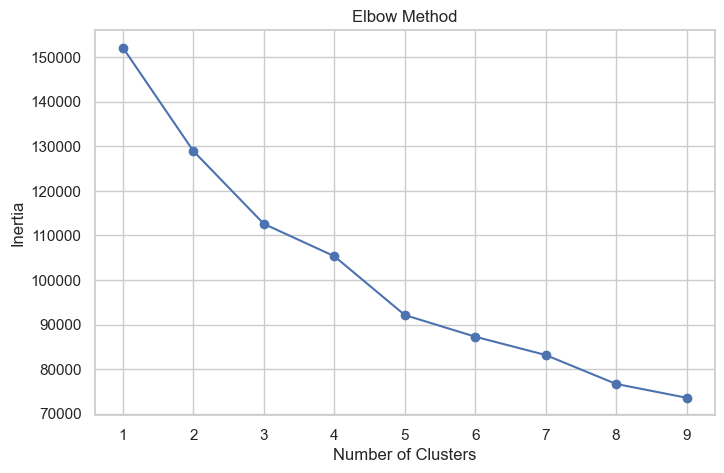

In [11]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

### 4.5 Applying KMeans Clustering

Based on the Elbow Method, we select the optimal number of clusters and apply KMeans clustering to segment customers.

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_cluster['Cluster'] = kmeans.fit_predict(scaled_data)

### 4.6 Cluster Analysis

We analyse each cluster by calculating the average values of features to understand customer behaviour patterns within each segment.

In [13]:
cluster_summary = df_cluster.groupby('Cluster').mean()
cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,5010.394668,0.966663,716.017789,450.235875,265.885977,5065.974690,0.327150,0.160632,0.218675,0.508502,15.770727,10.345957,8208.653578,4173.817878,2214.536286,0.040025,11.416581
1,108.430006,0.412096,350.247868,190.521089,160.197189,299.482324,0.320591,0.072760,0.234912,0.035072,0.730330,4.812374,3632.112008,1036.853064,172.183554,0.253704,11.217888
2,1253.817942,0.974758,2182.022178,1241.768493,940.517248,234.564524,0.928413,0.390217,0.748106,0.041717,0.807569,32.727389,5121.987288,2148.583305,778.937414,0.282970,11.729314
3,1495.324927,0.966467,283.482824,210.004454,73.794186,782.285268,0.207097,0.098032,0.108717,0.157514,2.988420,3.665380,3216.349960,947.961448,805.685810,0.022886,11.482482


### 4.7 Cluster Visualisation

We visualise customer segments to better understand how clusters differ in terms of spending and credit usage.

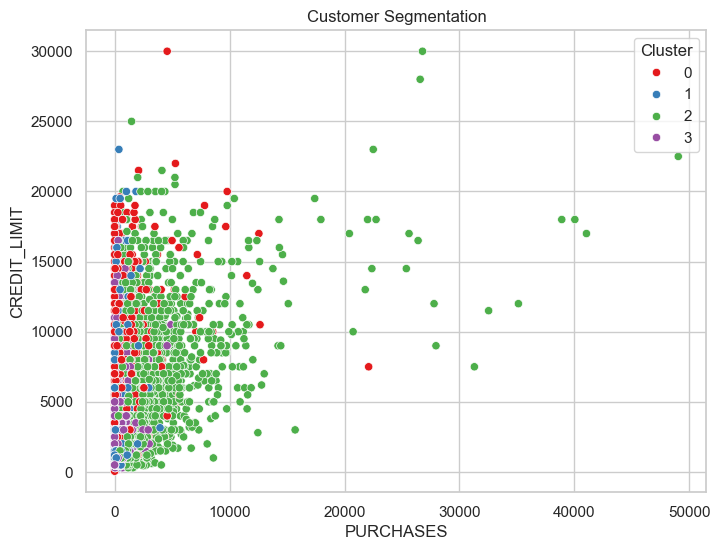

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_cluster['PURCHASES'],
    y=df_cluster['CREDIT_LIMIT'],
    hue=df_cluster['Cluster'],
    palette='Set1'
)
plt.title("Customer Segmentation")
plt.show()

### 4.8 Interpretation of Clusters

The clustering results reveal distinct customer segments:

- **Cluster 0**: High spending and high credit usage — likely premium or high-value customers.
- **Cluster 1**: Low activity customers — minimal transactions and engagement.
- **Cluster 2**: High cash advance users — potentially financially stressed or higher risk.
- **Cluster 3**: Moderate usage customers — balanced financial behaviour.

These insights can help businesses:
- Target marketing strategies
- Identify high-value customers
- Monitor potentially risky behaviour

## 5. Credit Risk Modelling

In this section, we build a machine learning model to predict whether a loan will default.

The objective is to support financial decision-making by identifying high-risk loans using historical financial and credit data.

We use classification models to predict the `defaulted` variable, which indicates whether a loan has defaulted.

### 5.1 Data Preparation

We prepare the loan portfolio dataset by:
- Selecting relevant features
- Removing unnecessary columns
- Handling categorical variables
- Defining the target variable

In [15]:
# Copy dataset
df_risk = loan_df.copy()

# Drop unnecessary columns
drop_cols = ['loan_id', 'origination_date', 'maturity_date', 'default_date']
df_risk = df_risk.drop(columns=drop_cols, errors='ignore')

df_risk.head()

,maturity_months,sector,loan_type,collateral,initial_rating,credit_score,ead,coupon_rate,leverage,interest_coverage,debt_to_equity,pd_annual,lgd,el,unexpected_loss,rwa,defaulted,survival_months,recovery_rate,loss_given_default
0,24,Technology,mortgage,secured,B,704,1035611.99,3.776,6.54,3.47,1.40,0.041076,0.7858,33426.80,161508.03,442905.14,0,24,NaN,NaN
1,48,Healthcare,term_loan,unsecured,A,702,800786.92,3.895,12.26,4.47,2.77,0.000887,0.7034,499.82,16771.62,6622.66,0,48,NaN,NaN
2,36,Real_Estate,bond,secured,BBB,699,4327864.12,4.365,8.98,6.02,2.18,0.002622,0.5503,6243.54,121781.72,82726.94,0,36,NaN,NaN
3,120,Real_Estate,term_loan,secured,B,641,3810461.19,3.749,13.12,5.93,1.75,0.041679,0.3541,56237.33,269661.85,745144.64,0,120,NaN,NaN
4,48,Energy,bond,unsecured,CCC,597,2925538.53,5.231,1.80,4.39,1.79,0.136071,0.6576,261778.69,659614.05,3468567.58,0,48,NaN,NaN


### 5.2 Target Variable

The target variable for this model is `defaulted`, where:
- 1 indicates a defaulted loan
- 0 indicates a non-defaulted loan

In [16]:
df_risk['defaulted'].value_counts()

defaulted
0    43050
1     6950
Name: count, dtype: int64

### 5.3 Encoding Categorical Variables

Machine learning models require numerical input.  
We convert categorical features such as sector, loan type, and collateral into numerical format using one-hot encoding.

In [17]:
df_risk = pd.get_dummies(df_risk, drop_first=True)

### 5.4 Feature Selection

We define:
- X as input features
- y as the target variable (defaulted)

In [18]:
X = df_risk.drop('defaulted', axis=1)
y = df_risk['defaulted']

### 5.5 Train-Test Split

We split the dataset into training and testing sets to evaluate model performance on unseen data.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 5.6 Model Training

We use a Random Forest classifier because it is robust, handles non-linear relationships, and performs well on structured data.

In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 5.7 Model Predictions

We generate predictions on the test dataset to evaluate model performance.

In [21]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

### 5.8 Model Evaluation

We evaluate the model using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

These metrics help us understand how well the model identifies high-risk loans.

In [22]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8594
           1       1.00      1.00      1.00      1406

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

ROC-AUC: 1.0


### 5.9 Confusion Matrix

The confusion matrix shows how many predictions were correct and incorrect, helping us understand model performance in detail.

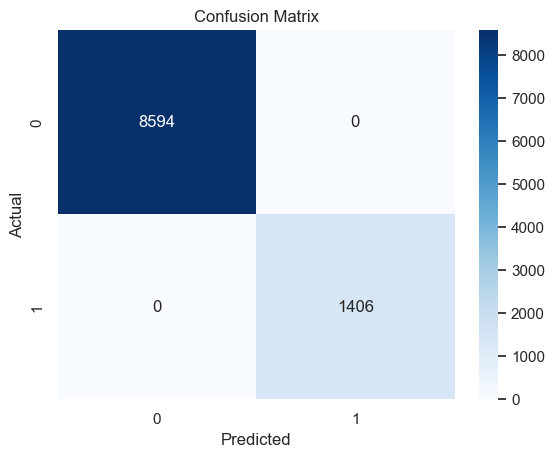

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 5.10 Expected Loss Calculation

Expected Loss is a key financial metric used in banking and risk management.

It is calculated as:

Expected Loss = PD × LGD × EAD

This represents the expected financial loss from a loan portfolio.

In [24]:
df_risk['Expected_Loss'] = (
    df_risk['pd_annual'] * df_risk['lgd'] * df_risk['ead']
)

df_risk[['pd_annual', 'lgd', 'ead', 'Expected_Loss']].head()

,pd_annual,lgd,ead,Expected_Loss
0,0.041076,0.7858,1035611.99,33426.987548
1,0.000887,0.7034,800786.92,499.623612
2,0.002622,0.5503,4327864.12,6244.617145
3,0.041679,0.3541,3810461.19,56236.820647
4,0.136071,0.6576,2925538.53,261778.034900


### 5.11 Feature Importance

We analyse which features contribute most to predicting credit risk.

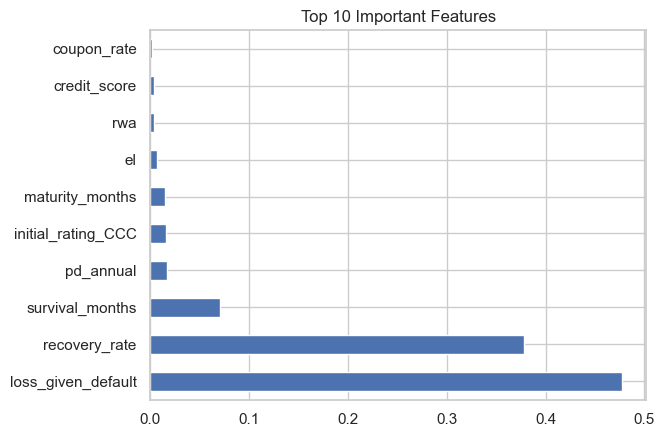

In [25]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

top_features.plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

### 5.12 Interpretation

The model successfully identifies patterns associated with loan defaults.

Key insights include:
- Financial ratios such as leverage and debt-to-equity significantly influence risk
- Higher PD values are strongly associated with defaults
- Certain sectors show higher default tendencies

This model can support:
- Better lending decisions
- Risk-based pricing
- Portfolio risk management

## 6. Combined Analysis: Customer Behaviour & Credit Risk

In this section, we combine insights from customer segmentation and credit risk modelling.

The objective is to understand how customer behaviour patterns relate to financial risk and how these insights can support better decision-making in financial institutions.

### 6.1 Linking Customer Segments to Risk Profiles

Although the clustering and risk datasets are separate, we can compare behavioural patterns with risk indicators to draw meaningful insights.

Customer behaviour such as high spending, frequent cash advances, and low repayment patterns can be linked to higher credit risk.

### 6.2 Business Insights

By combining both analyses, we identify the following key insights:

- Customers with high cash advance usage tend to exhibit higher financial risk behaviour.
- High-spending customers with strong repayment patterns represent valuable and low-risk segments.
- Low-activity customers may require engagement strategies but typically present lower immediate risk.
- Financial ratios such as leverage and debt-to-equity are strong indicators of default risk.

These insights enable financial institutions to:
- Segment customers for targeted marketing
- Improve credit risk assessment strategies
- Enhance portfolio risk management

### 6.3 Strategic Recommendations

Based on the analysis, the following recommendations are proposed:

- Offer premium services and rewards to high-value, low-risk customers.
- Monitor and manage high-risk customers with stricter credit policies.
- Develop personalised financial products based on customer segments.
- Use predictive models to support lending decisions and reduce default rates.

## 7. Ethical Considerations

The use of machine learning in financial decision-making raises several important ethical considerations.

### Bias and Fairness
Machine learning models may inherit biases from historical data, potentially leading to unfair treatment of certain groups. It is essential to ensure fairness in lending decisions.

### Privacy and Data Protection
Financial data is highly sensitive. Proper data protection measures must be in place to comply with regulations such as GDPR.

### Transparency and Explainability
Complex models such as Random Forest can act as black boxes. It is important to ensure that decisions can be explained to stakeholders and customers.

### Accountability
Financial institutions must take responsibility for decisions made by AI systems, especially when they impact individuals' access to credit.

### Responsible AI Use
Machine learning should be used to support human decision-making rather than fully automate critical financial decisions.

## 8. Conclusion

This project demonstrates how machine learning can be applied to both customer segmentation and credit risk modelling.

By combining unsupervised and supervised learning techniques, we were able to:
- Identify meaningful customer segments
- Predict loan default risk
- Estimate expected financial losses

The integration of behavioural insights and risk modelling provides a powerful framework for data-driven financial decision-making.

Overall, this project highlights the importance of combining technical modelling with business understanding and ethical responsibility.

In [26]:
import os

os.makedirs("../outputs/figures", exist_ok=True)

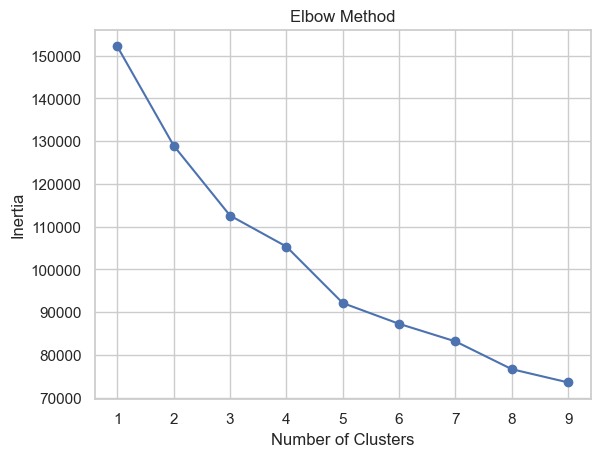

In [27]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.savefig("../outputs/figures/elbow_method.png")
plt.show()

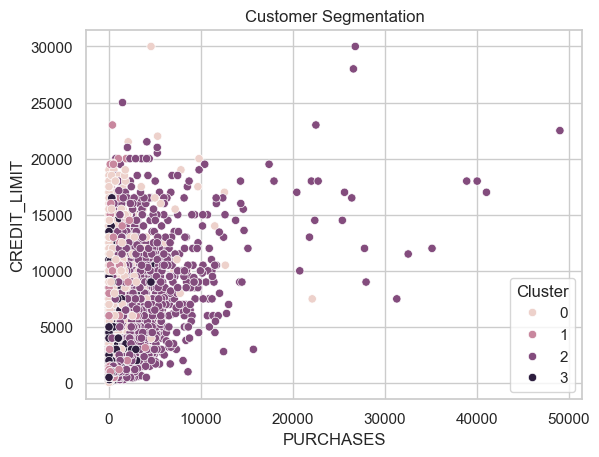

In [28]:
plt.figure()
sns.scatterplot(
    x=df_cluster['PURCHASES'],
    y=df_cluster['CREDIT_LIMIT'],
    hue=df_cluster['Cluster']
)
plt.title("Customer Segmentation")
plt.savefig("../outputs/figures/customer_segmentation.png")
plt.show()

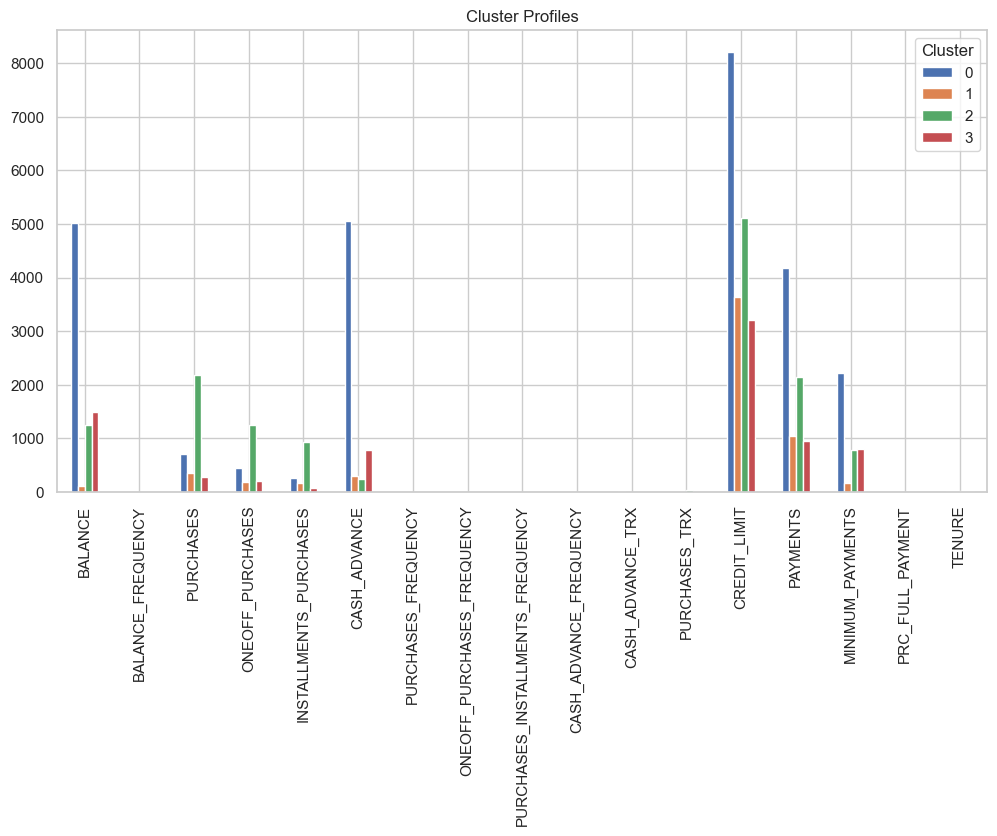

In [29]:
cluster_summary = df_cluster.groupby('Cluster').mean()

cluster_summary.T.plot(kind='bar', figsize=(12,6))
plt.title("Cluster Profiles")
plt.savefig("../outputs/figures/cluster_profiles.png")
plt.show()

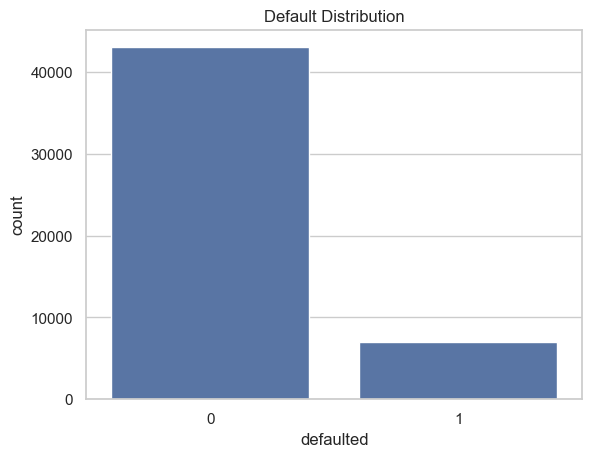

In [30]:
sns.countplot(x=loan_df['defaulted'])
plt.title("Default Distribution")
plt.savefig("../outputs/figures/default_distribution.png")
plt.show()

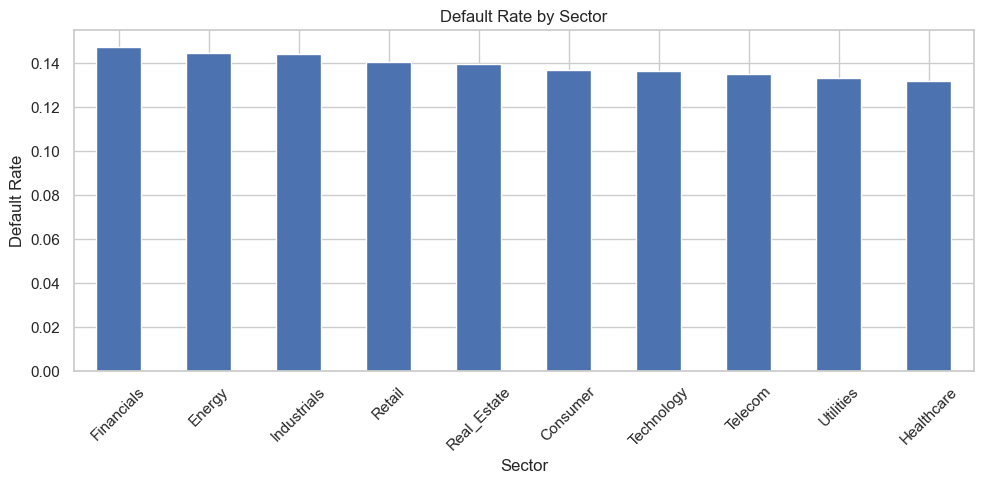

In [38]:
sector_defaults = loan_df.groupby('sector')['defaulted'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sector_defaults.plot(kind='bar')
plt.title("Default Rate by Sector")
plt.xlabel("Sector")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/sector_defaults.png")
plt.show()

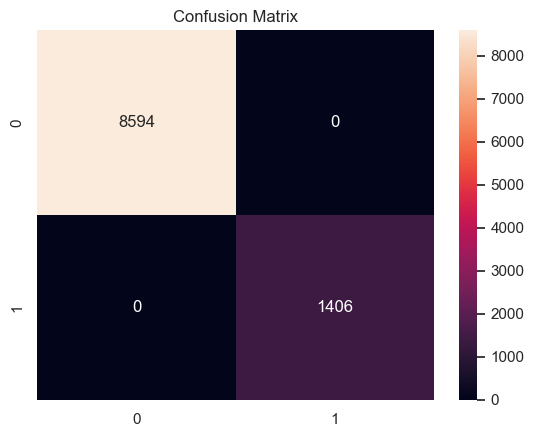

In [32]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.savefig("../outputs/figures/confusion_matrix.png")
plt.show()

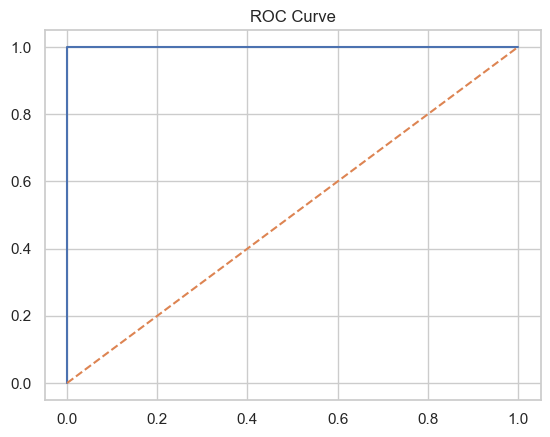

In [33]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.savefig("../outputs/figures/roc_curve.png")
plt.show()

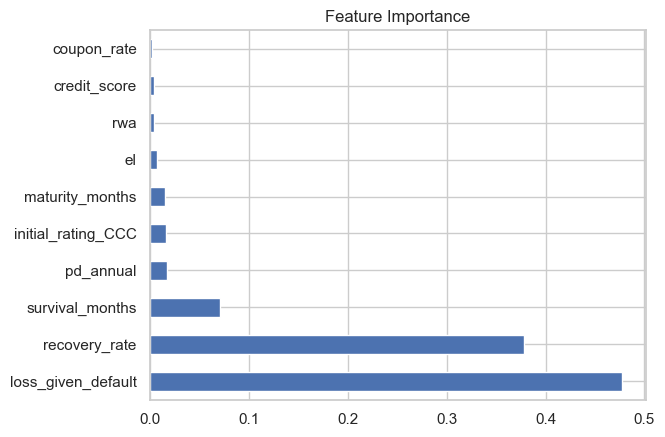

In [34]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

top_features.plot(kind='barh')
plt.title("Feature Importance")
plt.savefig("../outputs/figures/feature_importance.png")
plt.show()

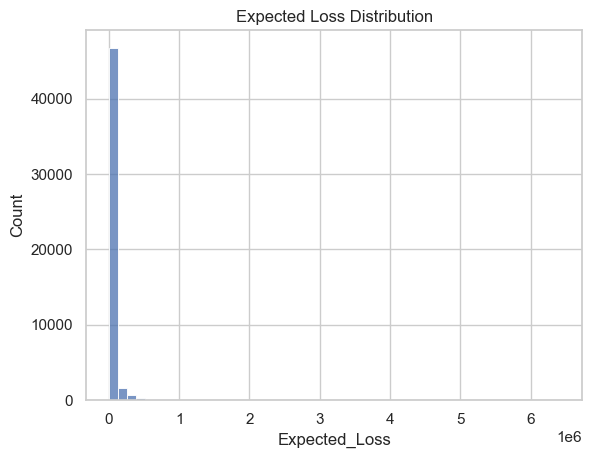

In [35]:
df_risk['Expected_Loss'] = df_risk['pd_annual'] * df_risk['lgd'] * df_risk['ead']

sns.histplot(df_risk['Expected_Loss'], bins=50)
plt.title("Expected Loss Distribution")
plt.savefig("../outputs/figures/expected_loss_distribution.png")
plt.show()

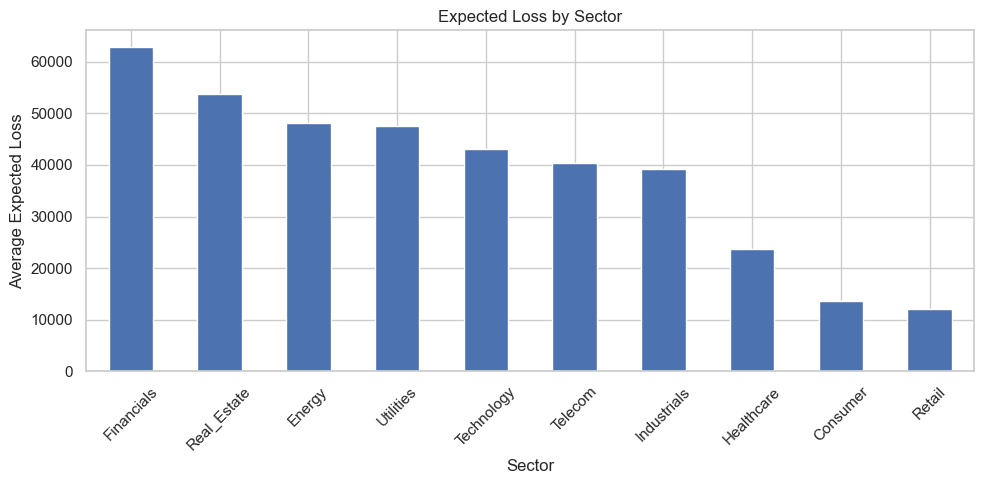

In [37]:
# Expected Loss from original loan data
loan_df['Expected_Loss'] = loan_df['pd_annual'] * loan_df['lgd'] * loan_df['ead']

sector_loss = loan_df.groupby('sector')['Expected_Loss'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sector_loss.plot(kind='bar')
plt.title("Expected Loss by Sector")
plt.xlabel("Sector")
plt.ylabel("Average Expected Loss")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/sector_expected_loss.png")
plt.show()